In [8]:
import pandas as pd
# Load the data
df = pd.read_csv('sym_GPT5_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (1001, 11)

Columns: ['timestamp', 'model_combination', 'recipe', 'experiment_file', 'classification', 'agent_0_role', 'agent_1_role', 'success_reason', 'num_interactions', 'num_sampled', 'processing_time_seconds']

First few rows:


,timestamp,model_combination,recipe,experiment_file,classification,agent_0_role,agent_1_role,success_reason,num_interactions,num_sampled,processing_time_seconds
0,2025-08-21T00:27:05.436521,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_11-18-07_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,91,18,20.385798
1,2025-08-21T00:27:24.766090,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_11-26-05_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,33,18,17.325647
2,2025-08-21T00:27:57.209059,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_12-05-50_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,97,18,30.439371
3,2025-08-21T00:28:28.317297,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_11-29-36_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,98,18,29.103736
4,2025-08-21T00:29:06.750311,Qwen_Qwen3-14B_Qwen_Qwen3-4B,baked_pumpkin_slices,experiment_2025-08-19_11-57-25_player0_Qwen_Qw...,fuzzy_hierarchy,0,0,No reason provided,51,18,36.427662


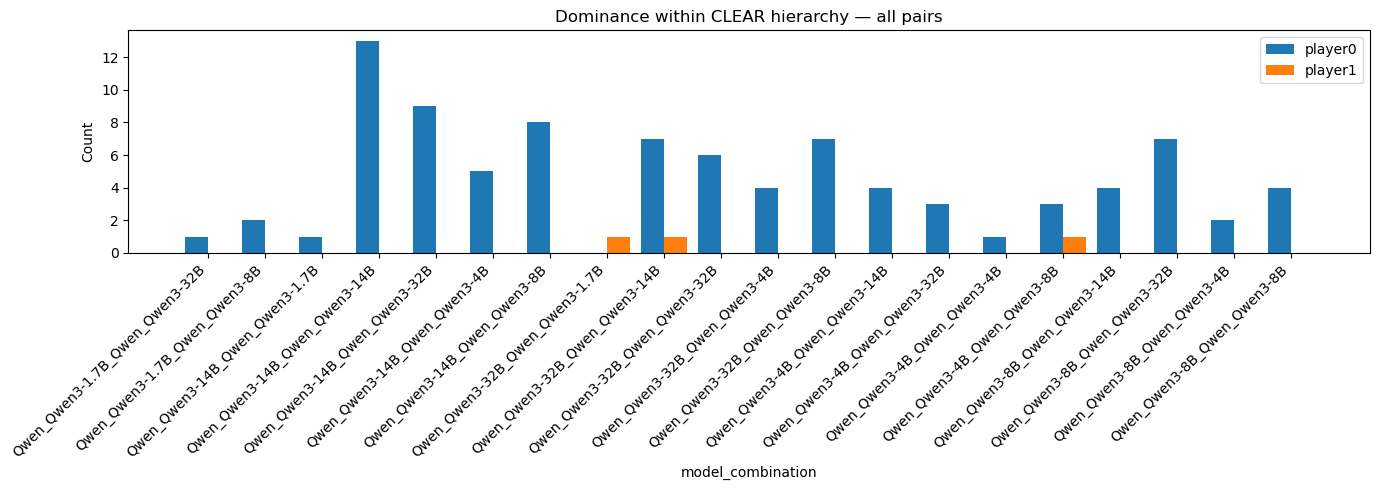

Computed dominance on 94 clear-hierarchy rows.
Figure saved under: /Users/3l3ktr4/dev/Collab-Overcooked/analysis/hierarchy_plots/ALL_pairs_dominance_counts_clear.png


In [17]:
# Aggregated dominance chart across all pairs (single figure).
# This cell replaces the per-pair plotting loop with one grouped bar chart
# (x-axis = model_combination, bars = counts for player0 vs player1).
# Unknowns remain included in the summary table but are omitted from the plot.
#
# Outputs:
#  - An interactive summary table in the UI.
#  - One PNG saved at /mnt/data/hierarchy_plots/ALL_pairs_dominance_counts_clear.png

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

if 'df' not in globals():
    print("DataFrame `df` not found. Please ensure your CSV is already loaded into a pandas DataFrame named `df`.")
else:
    # Make a working copy
    _df = df.copy()

    # Ensure minimal normalization for classification if needed
    if "classification_norm" not in _df.columns:
        def _norm_class(x):
            if pd.isna(x):
                return np.nan
            s = str(x).strip().lower().replace("-", "_")
            if s == "clear_hierarchy":
                return "clear hierarchy"
            if s == "fuzzy_hierarchy":
                return "fuzzy hierarchy"
            if s == "no_hierarchy":
                return "no hierarchy"
            return s  # best-effort fallback
        _df["classification_norm"] = _df["classification"].apply(_norm_class)

    # Filter to CLEAR hierarchy only
    clear_mask = _df["classification_norm"].eq("clear hierarchy") | _df["classification"].astype(str).str.lower().str.contains("clear")
    clear_df = _df.loc[clear_mask].copy()

    # Helper to test equality to 1, robust to strings/nans/bools
    def _is_one(val) -> bool:
        if pd.isna(val):
            return False
        if isinstance(val, (bool, np.bool_)):
            return bool(val) is True
        try:
            return float(val) == 1.0
        except Exception:
            return str(val).strip() == "1"

    # Assign dominance label per row
    def _dominant(row):
        p0 = _is_one(row.get("agent_0_role"))
        p1 = _is_one(row.get("agent_1_role"))
        if p0 and not p1:
            return "player0"
        if p1 and not p0:
            return "player1"
        return "unknown"

    clear_df["dominant"] = clear_df.apply(_dominant, axis=1)

    # Aggregate counts by pair
    dom_counts = (
        clear_df.groupby(["model_combination", "dominant"])
                .size().unstack(fill_value=0)
    )
    for col in ("player0", "player1", "unknown"):
        if col not in dom_counts.columns:
            dom_counts[col] = 0
    dom_counts = dom_counts[["player0", "player1", "unknown"]]

    # Display summary table
    if display_dataframe_to_user is not None:
        try:
            display_dataframe_to_user("Dominance (player0 vs player1) within CLEAR hierarchy — by pair", dom_counts.reset_index())
        except Exception:
            pass

    # Prepare a single aggregated chart with grouped bars per pair for player0 vs player1
    OUTPUT_DIR = Path("./hierarchy_plots")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUTPUT_DIR / "ALL_pairs_dominance_counts_clear.png"

    # Data for plotting (omit unknowns)
    pairs = dom_counts.index.tolist()
    p0_vals = dom_counts["player0"].to_numpy()
    p1_vals = dom_counts["player1"].to_numpy()

    n = len(pairs)
    if n == 0 or (p0_vals.sum() + p1_vals.sum()) == 0:
        print("No unique dominance counts (player0/player1) to plot for CLEAR hierarchy.")
    else:
        x = np.arange(n)
        width = 0.4

        # Dynamic figure width for readability
        fig_width = max(8.0, 0.6 * n + 2.0)
        plt.figure(figsize=(fig_width, 5.0))

        plt.bar(x - width/2, p0_vals, width, label="player0")
        plt.bar(x + width/2, p1_vals, width, label="player1")

        plt.title("Dominance within CLEAR hierarchy — all pairs")
        plt.xlabel("model_combination")
        plt.ylabel("Count")
        plt.xticks(x, pairs, rotation=45, ha="right")

        # Add legend and layout
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_path, dpi=150)
        plt.show()

    print(f"Computed dominance on {len(clear_df)} clear-hierarchy rows.")
    print(f"Figure saved under: {out_path.resolve()}")
